<h1 style="color:gold">Convolutional Neural Nets</h1>


In [67]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from sklearn.datasets import load_sample_images
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms.v2 as T
import torch.nn.functional as F
from functools import partial
import torchmetrics

In [68]:
device = "mps"

In [69]:
sample_images = np.stack(load_sample_images()["images"])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255

In [70]:
sample_images.shape

torch.Size([2, 427, 640, 3])

In [71]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

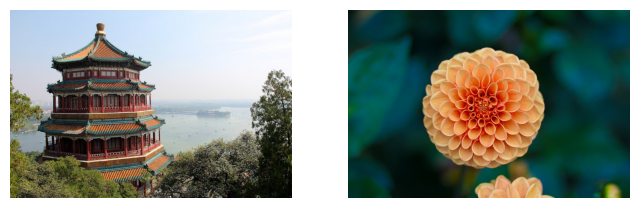

In [72]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")


plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)

In [73]:
# Let's reschape the pixel values to 0-1
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

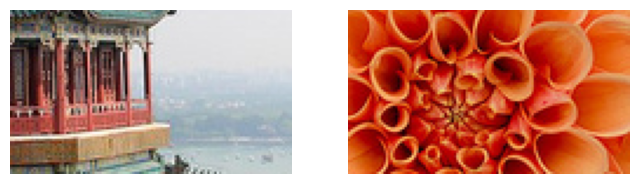

In [74]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(cropped_images[0])
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [75]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
fmaps = conv_layer(cropped_images)

In [76]:
fmaps.shape

torch.Size([2, 32, 64, 114])

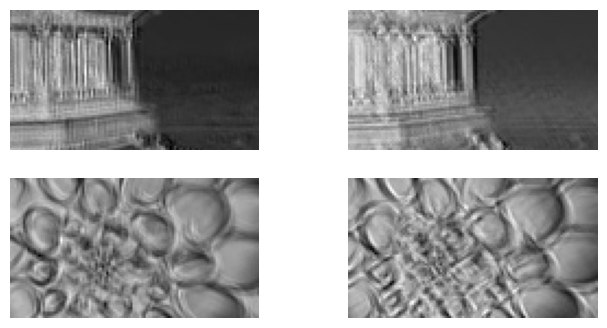

In [77]:
plt.figure(figsize=(8, 4))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx].detach(), cmap="gray")
        plt.axis("off")
plt.show()

In [78]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding="same")
fmaps = conv_layer(cropped_images)

In [79]:
fmaps.shape

torch.Size([2, 32, 70, 120])

In [80]:
conv_layer.weight.shape

torch.Size([32, 3, 7, 7])

In [81]:
conv_layer.bias.shape

torch.Size([32])

In [82]:
max_pool = nn.MaxPool2d(kernel_size=2)

In [83]:
# Implemtning depthwise pooling
from typing import Any


class DepthPool(torch.nn.Module):
    def __init__(self, kernel_size, stride=None, padding=0) -> None:
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding

    def forward(self, inputs):
        batch, channels, height, width = inputs.shape
        Z = inputs.view(batch, channels, height * width)
        Z = Z.permute(0, 2, 1)
        Z = F.max_pool1d(
            Z, kernel_size=self.kernel_size, stride=self.stride, padding=self.padding
        )
        Z = Z.permute(0, 2, 1)
        return Z.view(batch, -1, height, width, width)

In [84]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)
output = global_avg_pool(cropped_images)

In [85]:
output = cropped_images.mean(dim=(2, 3), keepdim=True)

## Implementing a basic CNN to tackle the Fashion MNIST dataset


In [86]:
# Defaultconv2d e exact conv2d dar cu niste argumente default cu kernel size 3 si padding samewhja
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")
model = nn.Sequential(
    DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128),
    nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256),
    nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=256 * 3 * 3, out_features=128),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)


In [87]:
# training function
# Functia trebuie sa ia ca input modelul datele si o metirca iar no isa intoarcem ca rezultat metrica
def evaluate_tm(model, data_loader, metric):
    # Bagam modelul in eval mode
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            metric.update(y_pred, y)
    return metric.compute().item()


def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            metric.update(y_pred, y)
            loss = loss_fn(y_pred, y)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        valid_metric = evaluate_tm(model, valid_loader, metric)
        history["valid_metrics"].append(valid_metric)
        print(
            f"Epoch {epoch + 1}/{n_epochs}, "
            f"train loss: {history['train_losses'][-1]:.4f}, "
            f"train metric: {history['train_metrics'][-1]:.4f}, "
            f"valid metric: {history['valid_metrics'][-1]:.4f}"
        )
    return history

In [88]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor
)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor
)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55000, 5_000]
)

In [89]:
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [90]:
total_params = sum(
    p.numel() for p in model.parameters()
)  # p.numel intoarce numarul total de elementer al unui tensor parameter
total_params

1413834

In [91]:
# Training the actualy model
n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(
    model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs
)

Epoch 1/20, train loss: 0.7861, train metric: 0.7065, valid metric: 0.8502
Epoch 2/20, train loss: 0.4728, train metric: 0.8369, valid metric: 0.8722
Epoch 3/20, train loss: 0.3953, train metric: 0.8659, valid metric: 0.8822
Epoch 4/20, train loss: 0.3547, train metric: 0.8799, valid metric: 0.8844
Epoch 5/20, train loss: 0.3278, train metric: 0.8880, valid metric: 0.8812
Epoch 6/20, train loss: 0.2999, train metric: 0.8971, valid metric: 0.8942
Epoch 7/20, train loss: 0.2890, train metric: 0.9033, valid metric: 0.8980
Epoch 8/20, train loss: 0.2735, train metric: 0.9076, valid metric: 0.8998
Epoch 9/20, train loss: 0.2592, train metric: 0.9120, valid metric: 0.9090
Epoch 10/20, train loss: 0.2501, train metric: 0.9149, valid metric: 0.8922
Epoch 11/20, train loss: 0.2403, train metric: 0.9187, valid metric: 0.9100
Epoch 12/20, train loss: 0.2312, train metric: 0.9212, valid metric: 0.9044
Epoch 13/20, train loss: 0.2221, train metric: 0.9246, valid metric: 0.9114
Epoch 14/20, train lo

### Xception

Separable Convolutional Layer


In [92]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.depthwise_conv = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size,
            stride=stride,
            padding=padding,
            groups=in_channels,
        )
        self.pointwise_conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, stride=1, padding=0
        )

    def forward(self, inputs):
        return self.pointwise_conv(self.depthwise_conv(inputs))


# Using pretrained Models


In [93]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

In [94]:
torch.hub.get_dir()

'/Users/cosminrosculet/.cache/torch/hub'

In [95]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [96]:
list(torchvision.models.get_model_weights("convnext_base"))

[ConvNeXt_Base_Weights.IMAGENET1K_V1]

In [97]:
from matplotlib import transforms


transforms = weights.transforms()
preprocessed_images = transforms(sample_images_permuted)

In [98]:
model.eval()
with torch.no_grad():
    y_logits = model(preprocessed_images.to(device))

In [99]:
y_pred = torch.argmax(y_logits, dim=1)
y_pred

tensor([698, 985], device='mps:0')

In [100]:
class_names = weights.meta["categories"]
print([class_names[class_id] for class_id in y_pred])
y_top3_logits, y_top3_class_ids = y_logits.topk(k=3, dim=1)
print([[class_names[class_id] for class_id in top3] for top3 in y_top3_class_ids])

['palace', 'daisy']
[['palace', 'monastery', 'lakeside'], ['daisy', 'pot', 'ant']]


In [101]:
y_top3_logits.softmax(dim=1)

tensor([[0.8618, 0.1185, 0.0197],
        [0.8106, 0.0964, 0.0930]], device='mps:0')

## Pretrained Models for Transfer Learning


In [102]:
DefaultFlowers102 = partial(
    torchvision.datasets.Flowers102,
    root="datasets",
    transform=weights.transforms(),
    download=True,
)
train_set = DefaultFlowers102(split="train")
valid_set = DefaultFlowers102(split="val")
test_set = DefaultFlowers102(split="test")


In [103]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_laoder = DataLoader(valid_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [104]:
print([name for name, child in model.named_children()])
print(child for name, child in list(model.named_modules()))

['features', 'avgpool', 'classifier']
<generator object <genexpr> at 0x37dd917d0>


In [105]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True, bias=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [106]:
n_classes = 102
model.classifier[2] = nn.Linear(1024, n_classes).to(device)

## Don't forget to freeze the weights


In [107]:
model.features

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True, bias=True)
  )
  (1): Sequential(
    (0): CNBlock(
      (block): Sequential(
        (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
        (1): Permute()
        (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True, bias=True)
        (3): Linear(in_features=128, out_features=512, bias=True)
        (4): GELU(approximate='none')
        (5): Linear(in_features=512, out_features=128, bias=True)
        (6): Permute()
      )
      (stochastic_depth): StochasticDepth(p=0.0, mode=row)
    )
    (1): CNBlock(
      (block): Sequential(
        (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
        (1): Permute()
        (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True, bias=True)
        (3): Linear(in_features=128, out_features=512, bi

In [108]:
# Freeze all the params

for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [109]:
n_epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters())
accuracy = torchvision = torchmetrics.Accuracy(task="multiclass", num_classes=102).to(
    device
)

results = train(
    model, optimizer, loss_fn, accuracy, train_loader, valid_laoder, n_epochs
)

Epoch 1/5, train loss: 4.3115, train metric: 0.1490, valid metric: 0.5755
Epoch 2/5, train loss: 3.0300, train metric: 0.6853, valid metric: 0.7549
Epoch 3/5, train loss: 2.0659, train metric: 0.8255, valid metric: 0.8284
Epoch 4/5, train loss: 1.3654, train metric: 0.8980, valid metric: 0.8549
Epoch 5/5, train loss: 0.9461, train metric: 0.9402, valid metric: 0.8725


In [110]:
results_on_test = train(
    model, optimizer, loss_fn, accuracy, train_loader, valid_laoder, n_epochs
)

Epoch 1/5, train loss: 0.6955, train metric: 0.9559, valid metric: 0.8735
Epoch 2/5, train loss: 0.5201, train metric: 0.9627, valid metric: 0.8882
Epoch 3/5, train loss: 0.4122, train metric: 0.9794, valid metric: 0.8980
Epoch 4/5, train loss: 0.3216, train metric: 0.9863, valid metric: 0.8931
Epoch 5/5, train loss: 0.2624, train metric: 0.9882, valid metric: 0.8912


# Again with unfreezing the whole model


In [111]:
for param in model.parameters():
    param.requires_grad = True

In [112]:
results = train(
    model, optimizer, loss_fn, accuracy, train_loader, valid_laoder, n_epochs
)

Epoch 1/5, train loss: 0.6763, train metric: 0.8108, valid metric: 0.8647
Epoch 2/5, train loss: 0.2448, train metric: 0.9304, valid metric: 0.8618
Epoch 3/5, train loss: 0.1552, train metric: 0.9618, valid metric: 0.8343
Epoch 4/5, train loss: 0.1110, train metric: 0.9696, valid metric: 0.8275
Epoch 5/5, train loss: 0.1362, train metric: 0.9598, valid metric: 0.8206


## Let's try now some data augumentation


In [113]:
transforms = T.Compose(
    [
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=30),
        T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Classification and Localization


In [114]:
model.classifier
# model.avgpool

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True, bias=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=102, bias=True)
)

In [115]:
# Modfiying the Convnext for localization
class FlowerLocator(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.localization_head = nn.Sequential(
            nn.Flatten(), nn.Linear(base_model.classifier[2].in_features, 4)
        )

    def forward(self, X):
        features = self.base_model.features(X)
        pool = self.base_model.avgpool(features)
        logits = self.base_model.classifier(pool)
        bbox = self.localization_head(pool)
        return logits, bbox


torch.manual_seed(42)
locator_model = FlowerLocator(model).to(device)

In [116]:
preproc_images = torch.randn(2, 3, 224, 224)
y_pred_logits, y_pred_bbox = locator_model(preprocessed_images.to(device))

In [117]:
# Create abounding box
import torchvision.tv_tensors

bbox = torchvision.tv_tensors.BoundingBoxes(
    torch.tensor([[377, 199, 248, 262]]), format="CXCYWH", canvas_size=(500, 754)
)

In [118]:
transforms(bbox)

BoundingBoxes([[ 90,  91, 120, 154]], format=BoundingBoxFormat.CXCYWH, canvas_size=(224, 224), clamping_mode=soft)

In [119]:
torch.manual_seed(42)
first_image, _ = torchvision.datasets.Flowers102(root="datasets", split="train")[0]

preproc_image, preproc_target = transforms((first_image, {"label": 0, "bbox": bbox}))
preproc_bbox = preproc_target["bbox"]

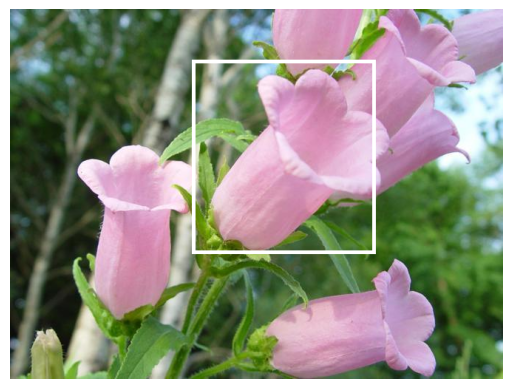

In [120]:
third_image, _ = torchvision.datasets.Flowers102(root="datasets", split="train")[20]
third_bbox = torchvision.tv_tensors.BoundingBoxes(
    torch.tensor([[370, 199, 248, 262]]),
    format="CXCYWH",
    canvas_size=(third_image.height, third_image.width),
)

p_image, _ = transforms((third_image, {"label": 0, "bbox": third_bbox}))

bbox_xyxy = torchvision.ops.box_convert(third_bbox, "cxcywh", "xyxy")
third_image_ts = T.ToImage()(third_image)
thirdimage_with_box = torchvision.utils.draw_bounding_boxes(
    third_image_ts, bbox_xyxy, width=5, colors="white"
)

plot_image(thirdimage_with_box)
plt.show()

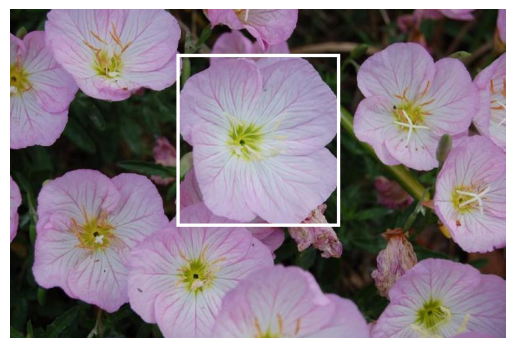

In [121]:
def get_image_with_bbox(image, bbox, width=5, color="white"):
    bbox_xyxy = torchvision.ops.box_convert(bbox, "cxcywh", "xyxy")
    return torchvision.utils.draw_bounding_boxes(
        image, bbox_xyxy, width=width, colors=color
    )


first_image_ts = T.ToImage()(first_image)
image_with_bbox = get_image_with_bbox(first_image_ts, bbox)
plot_image(image_with_bbox)
plt.show()

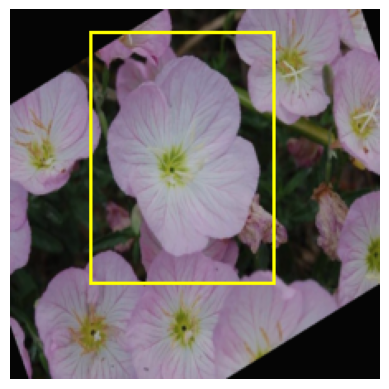

In [122]:
def denormalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    mean = torch.tensor(mean, dtype=image.dtype, device=image.device).view(-1, 1, 1)
    std = torch.tensor(std, dtype=image.dtype, device=image.device).view(-1, 1, 1)
    return image * std + mean


image_with_bbox2 = get_image_with_bbox(
    denormalize(preproc_image), preproc_bbox, width=2, color="yellow"
)
plot_image(image_with_bbox2)

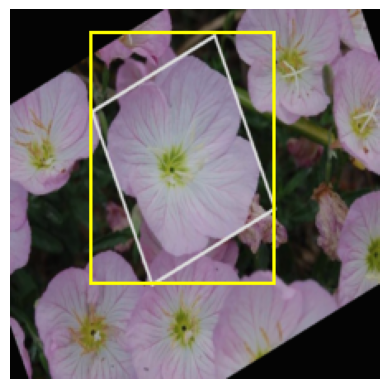

In [123]:
torch.manual_seed(42)

preproc_image2, preproc_target2 = transforms(
    (image_with_bbox, {"label": 0, "bbox": bbox})
)
image_and_bbox3 = get_image_with_bbox(
    denormalize(preproc_image2), preproc_target2["bbox"], width=2, color="yellow"
)
plot_image(image_and_bbox3)

In [124]:
bboxes = [
    torchvision.tv_tensors.BoundingBoxes(
        [[377, 199, 248, 262]], format="CXCYWH", canvas_size=(500, 754)
    ),
    torchvision.tv_tensors.BoundingBoxes(
        [[314, 248, 437, 445]], format="CXCYWH", canvas_size=(500, 624)
    ),
]


In [125]:
class FlowersWithBbox(torch.utils.data.Dataset):
    def __init__(self, root, bboxes, transform=None, split="train"):
        self.image_dataset = torchvision.datasets.Flowers102(root=root, split=split)
        self.bboxes = bboxes
        self.transform = transform
        print(type(self.image_dataset))

    def __len__(self):
        return len(self.bboxes)

    def __getitem__(self, index):
        raw_image, label = self.image_dataset[index]
        image = torchvision.tv_tensors.Image(raw_image)
        bbox = self.bboxes[index]
        preproc_image, preproc_bbox = self.transform(image, bbox)
        return preproc_image, {"label": label, "bbox": preproc_bbox}


train_set_with_bboxes = FlowersWithBbox("datasets", bboxes, transform=transforms)

<class 'torchvision.datasets.flowers102.Flowers102'>


In [126]:
train_loader_with_bboxes = DataLoader(train_set_with_bboxes, batch_size=2)
for images, label_and_bbox in train_loader_with_bboxes:
    label = label_and_bbox["label"]
    bbox = label_and_bbox["bbox"]

## Object Detection


In [127]:
from ultralytics import YOLO

model = YOLO("yolov9m.pt")
images = ["https://homl.info/soccer.jpg", "https://homl.info/traffic.jpg"]
results = model(images)


0: 640x640 5 persons, 2 sports balls, 286.9ms
1: 640x640 3 persons, 7 cars, 1 motorcycle, 11 trucks, 286.9ms
Speed: 4.8ms preprocess, 286.9ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)


In [128]:
results[0].summary()[0]

{'name': 'sports ball',
 'class': 32,
 'confidence': 0.96214,
 'box': {'x1': 245.3573, 'y1': 286.03003, 'x2': 300.62506, 'y2': 343.57184}}

In [129]:
my_video = "https://homl.info/cars.mp4"
results = model.track(source=my_video, stream=True, save=True)
for frame_results in results:
    summary = frame_results.summary()
    track_ids = [obj["track_id"] for obj in summary]
    print("Track ids:", track_ids)


Found https://homl.info/cars.mp4 locally at cars.mp4
video 1/1 (frame 1/243) /Users/cosminrosculet/Developer/Hands-on ML with Pytorch and Scikit/ConvolutionalNeuralNets/cars.mp4: 384x640 7 cars, 118.9ms
Track ids: [1, 2, 3, 4, 5, 6, 7]
video 1/1 (frame 2/243) /Users/cosminrosculet/Developer/Hands-on ML with Pytorch and Scikit/ConvolutionalNeuralNets/cars.mp4: 384x640 7 cars, 115.6ms
Track ids: [1, 2, 3, 4, 5, 6, 7]
video 1/1 (frame 3/243) /Users/cosminrosculet/Developer/Hands-on ML with Pytorch and Scikit/ConvolutionalNeuralNets/cars.mp4: 384x640 7 cars, 113.3ms
Track ids: [1, 2, 3, 4, 5, 6, 7]
video 1/1 (frame 4/243) /Users/cosminrosculet/Developer/Hands-on ML with Pytorch and Scikit/ConvolutionalNeuralNets/cars.mp4: 384x640 7 cars, 115.2ms
Track ids: [1, 2, 3, 4, 5, 6, 7]
video 1/1 (frame 5/243) /Users/cosminrosculet/Developer/Hands-on ML with Pytorch and Scikit/ConvolutionalNeuralNets/cars.mp4: 384x640 7 cars, 112.4ms
Track ids: [1, 2, 3, 4, 5, 6, 7]
video 1/1 (frame 6/243) /Users/

In [130]:
from pathlib import Path
import urllib.request


def download_file(url, path):
    path = Path(path)
    if not path.is_file():
        path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(url, path)


download_file("https://homl.info/soccer.jpg", "datasets/images/soccer.jpg")


In [131]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
import torch

weights = FCN_ResNet50_Weights.DEFAULT
model = fcn_resnet50(weights=weights)
model.eval()

img = PIL.Image.open("datasets/images/soccer.jpg")
transform = weights.transforms()
batch = transform(img).unsqueeze(0)  # unsqueeze() adds a dimension of size 1

with torch.no_grad():
    masks = model(batch)["out"].softmax(dim=1)

class_names = weights.meta["categories"]
name_to_id = {name: class_id for class_id, name in enumerate(class_names)}
mask = masks[0, name_to_id["person"]]

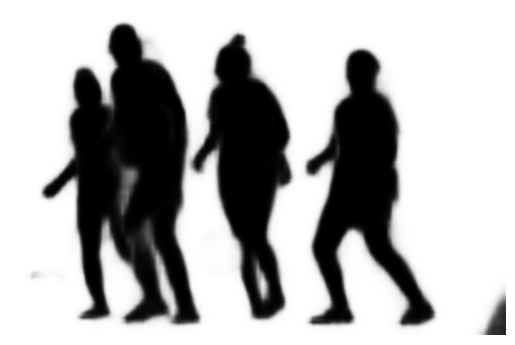

In [132]:
import matplotlib.pyplot as plt

plt.imshow(mask, cmap="binary")
plt.axis("off")
plt.show()

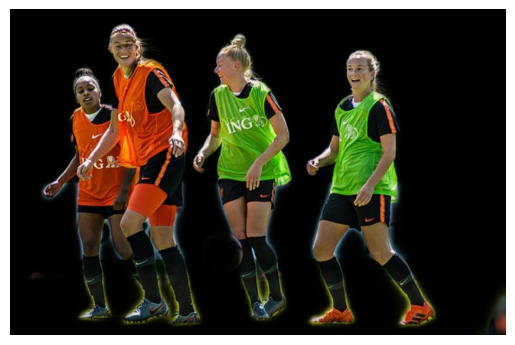

In [133]:
masked_image = mask.unsqueeze(0) * denormalize(batch.squeeze(0))
plot_image(masked_image)

In [134]:
def maximum_precisions(precisions):
    return np.flip(np.maximum.accumulate(np.flip(precisions)))

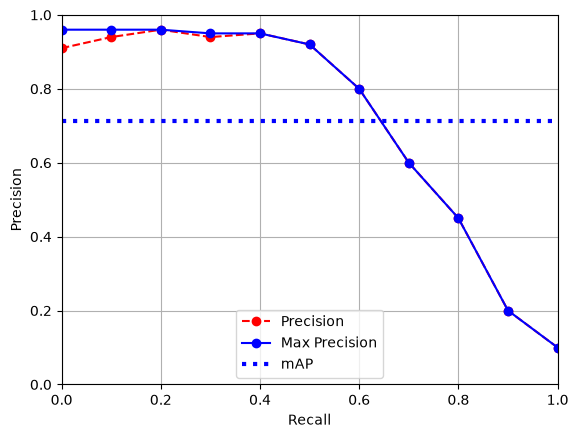

In [135]:
import numpy as np

recalls = np.linspace(0, 1, 11)

precisions = [0.91, 0.94, 0.96, 0.94, 0.95, 0.92, 0.80, 0.60, 0.45, 0.20, 0.10]
max_precisions = maximum_precisions(precisions)
mAP = max_precisions.mean()
plt.plot(recalls, precisions, "ro--", label="Precision")
plt.plot(recalls, max_precisions, "bo-", label="Max Precision")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [mAP, mAP], "b:", linewidth=3, label="mAP")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower center")
plt.show()